# Understanding Attention Mechanisms: Improving Sequence Learning in Neural Networks

This notebook supports a tutorial on how attention mechanisms improve sequence modelling in neural networks. The experiment compares:

1. a baseline recurrent neural network (RNN), and  
2. an attention-enhanced RNN  

using the IMDB movie review dataset for binary sentiment classification.

## Objectives

The notebook is designed to:

- preprocess the IMDB review dataset for sequence modelling
- implement a baseline RNN classifier
- implement an attention-based RNN classifier
- compare model performance using validation loss and accuracy
- visualise attention weights to interpret which tokens influence predictions

## Workflow

The notebook is organised into the following stages:

1. data loading and preprocessing  
2. vocabulary construction and sequence encoding  
3. baseline RNN implementation  
4. attention-based RNN implementation  
5. model training and evaluation  
6. attention visualisation and interpretation  

## Expected Outputs

Running this notebook should reproduce:

- training and validation performance for both models
- comparison plots for validation loss and accuracy
- attention weight visualisation for a sample review

## Reproducibility

To support reproducibility, random seeds are fixed where possible and all required libraries are imported at the beginning of the notebook.

In [1]:
# Core Python libraries
import re
import random
from collections import Counter

# Numerical and data handling
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Hugging Face dataset loader
from datasets import load_dataset

In [2]:
# Setting seeds makes the experiment reproducible.
# This is important because the assignment requires code that can be run by another user.

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Use GPU if available, otherwise fall back to CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
# The IMDB dataset contains movie reviews labelled as positive (1) or negative (0).
# It is a suitable dataset for demonstrating attention because sentiment often depends
# on a small number of important words in a long sequence.

dataset = load_dataset("imdb")

train_data = dataset["train"]
test_data = dataset["test"]

print(train_data[0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

In [4]:
# To make experimentation faster during development, we use a subset of the data.
# You can increase these numbers later for final results if your machine can handle it.

TRAIN_SAMPLES = 8000
TEST_SAMPLES = 2000

train_texts = train_data["text"][:TRAIN_SAMPLES]
train_labels = train_data["label"][:TRAIN_SAMPLES]

test_texts = test_data["text"][:TEST_SAMPLES]
test_labels = test_data["label"][:TEST_SAMPLES]

print("Training examples:", len(train_texts))
print("Test examples:", len(test_texts))

Training examples: 8000
Test examples: 2000


In [5]:
def clean_text(text):
    """
    Basic text cleaning function.

    This function:
    - converts text to lowercase
    - removes HTML tags such as <br />
    - removes non-alphabetic characters except spaces
    - collapses extra whitespace

    A simple cleaner is enough for this tutorial because our goal is to compare
    model behaviour rather than build a production NLP pipeline.
    """
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)          # Remove HTML tags
    text = re.sub(r"[^a-z\s]", " ", text)       # Keep only letters and spaces
    text = re.sub(r"\s+", " ", text).strip()    # Remove extra spaces
    return text

def tokenize(text):
    """
    Tokenise text by splitting on whitespace.

    This is a simple word-level tokenizer.
    It is easy to understand and sufficient for a tutorial setting.
    """
    return clean_text(text).split()

In [6]:
# We create a vocabulary that maps words to integer IDs.
# Neural networks cannot work directly with raw text, so words must be converted into numbers.

MAX_VOCAB_SIZE = 20000
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

counter = Counter()

for text in train_texts:
    tokens = tokenize(text)
    counter.update(tokens)

# Keep the most common words
most_common_tokens = counter.most_common(MAX_VOCAB_SIZE - 2)

# Reserve index 0 for padding and 1 for unknown words
vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}

for word, _ in most_common_tokens:
    vocab[word] = len(vocab)

# Reverse vocabulary can help when visualising attention later
idx_to_word = {idx: word for word, idx in vocab.items()}

print("Vocabulary size:", len(vocab))

Vocabulary size: 20000


In [7]:
MAX_LEN = 200

def encode_text(text, vocab, max_len=MAX_LEN):
    """
    Convert a review into a fixed-length sequence of word IDs.

    Steps:
    1. Tokenise the text
    2. Replace each token with its vocabulary index
    3. Truncate long reviews
    4. Pad short reviews to a fixed length

    Fixed-length sequences make batching efficient during training.
    """
    tokens = tokenize(text)
    token_ids = [vocab.get(token, vocab[UNK_TOKEN]) for token in tokens]

    # Truncate to max length
    token_ids = token_ids[:max_len]

    # Pad with PAD token if shorter than max length
    if len(token_ids) < max_len:
        token_ids += [vocab[PAD_TOKEN]] * (max_len - len(token_ids))

    return token_ids

In [8]:
example_encoded = encode_text(train_texts[0], vocab)
print(example_encoded[:20])
print("Sequence length:", len(example_encoded))

[9, 1199, 9, 219, 1825, 4389, 42, 65, 309, 966, 78, 5, 33, 2, 8091, 12, 2866, 8, 57, 8]
Sequence length: 200


In [9]:
class IMDBDataset(Dataset):
    """
    Custom PyTorch Dataset for IMDB reviews.

    Each item returned by this dataset consists of:
    - a tensor containing the encoded review
    - a tensor containing the sentiment label
    """
    def __init__(self, texts, labels, vocab, max_len=MAX_LEN):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoded = encode_text(self.texts[idx], self.vocab, self.max_len)
        label = self.labels[idx]

        return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label, dtype=torch.float32)
        )

In [10]:
# Split the original training subset into training and validation sets.
train_x, val_x, train_y, val_y = train_test_split(
    train_texts,
    train_labels,
    test_size=0.2,
    random_state=SEED,
    stratify=train_labels
)

train_dataset = IMDBDataset(train_x, train_y, vocab)
val_dataset = IMDBDataset(val_x, val_y, vocab)
test_dataset = IMDBDataset(test_texts, test_labels, vocab)

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 100
Validation batches: 25
Test batches: 32


In [11]:
class SimpleRNNClassifier(nn.Module):
    """
    Baseline recurrent neural network for binary sentiment classification.

    Architecture:
    1. Embedding layer converts token IDs into dense vectors
    2. RNN processes the sequence word by word
    3. Final hidden state is used as a summary of the whole review
    4. Fully connected layer predicts sentiment

    This baseline is useful because it lets us test the key limitation:
    the model must compress the whole sequence into one hidden representation.
    """
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x shape: (batch_size, sequence_length)

        embedded = self.embedding(x)
        # embedded shape: (batch_size, sequence_length, embedding_dim)

        output, hidden = self.rnn(embedded)
        # output shape: (batch_size, sequence_length, hidden_dim)
        # hidden shape: (1, batch_size, hidden_dim)

        final_hidden = hidden.squeeze(0)
        # final_hidden shape: (batch_size, hidden_dim)

        logits = self.fc(final_hidden).squeeze(1)
        # logits shape: (batch_size,)

        return logits

In [12]:
class AttentionRNNClassifier(nn.Module):
    """
    RNN with an attention mechanism.

    Key idea:
    Instead of relying only on the final hidden state, the model learns
    which time steps in the sequence are most important.

    The attention mechanism assigns a weight to each hidden state.
    These weights are used to compute a weighted sum called the context vector.
    The context vector is then used for classification.

    This makes the model more flexible and more interpretable.
    """
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        # Attention scoring layer: maps each hidden state to a single score
        self.attention = nn.Linear(hidden_dim, 1)

        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x, return_attention=False):
        # x shape: (batch_size, sequence_length)

        embedded = self.embedding(x)
        output, hidden = self.rnn(embedded)
        # output shape: (batch_size, sequence_length, hidden_dim)

        # Compute raw attention scores for each time step
        attn_scores = self.attention(output).squeeze(-1)
        # attn_scores shape: (batch_size, sequence_length)

        # Convert scores into probabilities
        attn_weights = torch.softmax(attn_scores, dim=1)
        # attn_weights shape: (batch_size, sequence_length)

        # Compute weighted sum of hidden states
        context = torch.sum(output * attn_weights.unsqueeze(-1), dim=1)
        # context shape: (batch_size, hidden_dim)

        logits = self.fc(context).squeeze(1)

        if return_attention:
            return logits, attn_weights

        return logits

In [13]:
def binary_accuracy_from_logits(logits, labels):
    """
    Convert raw model outputs (logits) into binary predictions
    and compute classification accuracy.
    """
    predictions = (torch.sigmoid(logits) >= 0.5).float()
    return (predictions == labels).float().mean().item()

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    """
    Train the model for one epoch.

    Returns:
    - average loss
    - average accuracy
    """
    model.train()

    total_loss = 0
    total_acc = 0

    for inputs, labels in dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(inputs)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += binary_accuracy_from_logits(logits, labels)

    avg_loss = total_loss / len(dataloader)
    avg_acc = total_acc / len(dataloader)

    return avg_loss, avg_acc

def evaluate(model, dataloader, criterion, device):
    """
    Evaluate the model without updating parameters.
    """
    model.eval()

    total_loss = 0
    total_acc = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            logits = model(inputs)
            loss = criterion(logits, labels)

            total_loss += loss.item()
            total_acc += binary_accuracy_from_logits(logits, labels)

    avg_loss = total_loss / len(dataloader)
    avg_acc = total_acc / len(dataloader)

    return avg_loss, avg_acc

In [14]:
# Hyperparameters
VOCAB_SIZE = len(vocab)
EMBEDDING_DIM = 100
HIDDEN_DIM = 128
EPOCHS = 5
LEARNING_RATE = 1e-3

baseline_model = SimpleRNNClassifier(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(baseline_model.parameters(), lr=LEARNING_RATE)

baseline_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        baseline_model, train_loader, optimizer, criterion, device
    )
    val_loss, val_acc = evaluate(
        baseline_model, val_loader, criterion, device
    )

    baseline_history["train_loss"].append(train_loss)
    baseline_history["train_acc"].append(train_acc)
    baseline_history["val_loss"].append(val_loss)
    baseline_history["val_acc"].append(val_acc)

    print(f"Baseline RNN | Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print("-" * 50)

Baseline RNN | Epoch 1/5
Train Loss: 0.0822 | Train Acc: 0.9853
Val Loss:   0.0207 | Val Acc:   0.9975
--------------------------------------------------
Baseline RNN | Epoch 2/5
Train Loss: 0.0374 | Train Acc: 0.9936
Val Loss:   0.0146 | Val Acc:   0.9988
--------------------------------------------------
Baseline RNN | Epoch 3/5
Train Loss: 0.0096 | Train Acc: 0.9988
Val Loss:   0.0011 | Val Acc:   1.0000
--------------------------------------------------
Baseline RNN | Epoch 4/5
Train Loss: 0.0041 | Train Acc: 0.9995
Val Loss:   0.0007 | Val Acc:   1.0000
--------------------------------------------------
Baseline RNN | Epoch 5/5
Train Loss: 0.0028 | Train Acc: 0.9997
Val Loss:   0.0005 | Val Acc:   1.0000
--------------------------------------------------


In [15]:
attention_model = AttentionRNNClassifier(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(attention_model.parameters(), lr=LEARNING_RATE)

attention_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        attention_model, train_loader, optimizer, criterion, device
    )
    val_loss, val_acc = evaluate(
        attention_model, val_loader, criterion, device
    )

    attention_history["train_loss"].append(train_loss)
    attention_history["train_acc"].append(train_acc)
    attention_history["val_loss"].append(val_loss)
    attention_history["val_acc"].append(val_acc)

    print(f"Attention RNN | Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print("-" * 50)

Attention RNN | Epoch 1/5
Train Loss: 0.0493 | Train Acc: 0.9986
Val Loss:   0.0011 | Val Acc:   1.0000
--------------------------------------------------
Attention RNN | Epoch 2/5
Train Loss: 0.0007 | Train Acc: 1.0000
Val Loss:   0.0004 | Val Acc:   1.0000
--------------------------------------------------
Attention RNN | Epoch 3/5
Train Loss: 0.0003 | Train Acc: 1.0000
Val Loss:   0.0041 | Val Acc:   0.9994
--------------------------------------------------
Attention RNN | Epoch 4/5
Train Loss: 0.0014 | Train Acc: 0.9998
Val Loss:   0.0002 | Val Acc:   1.0000
--------------------------------------------------
Attention RNN | Epoch 5/5
Train Loss: 0.0002 | Train Acc: 1.0000
Val Loss:   0.0001 | Val Acc:   1.0000
--------------------------------------------------


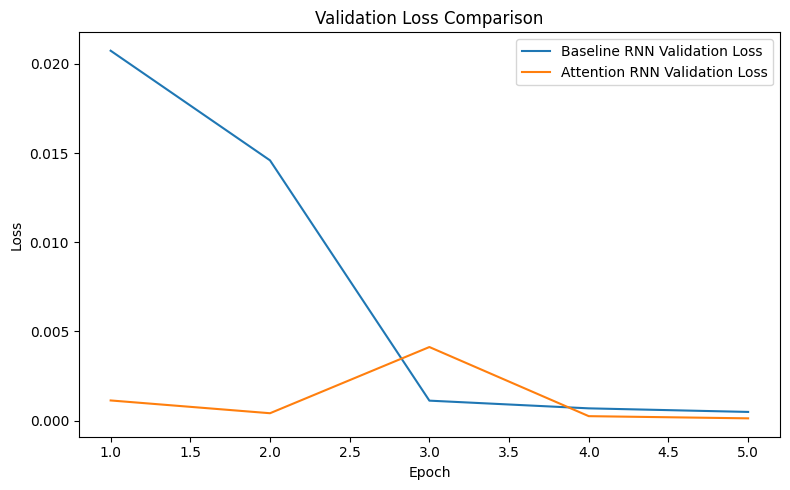

In [16]:
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, baseline_history["val_loss"], label="Baseline RNN Validation Loss")
plt.plot(epochs, attention_history["val_loss"], label="Attention RNN Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Loss Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("validation_loss_comparison.png", dpi=300)
plt.show()

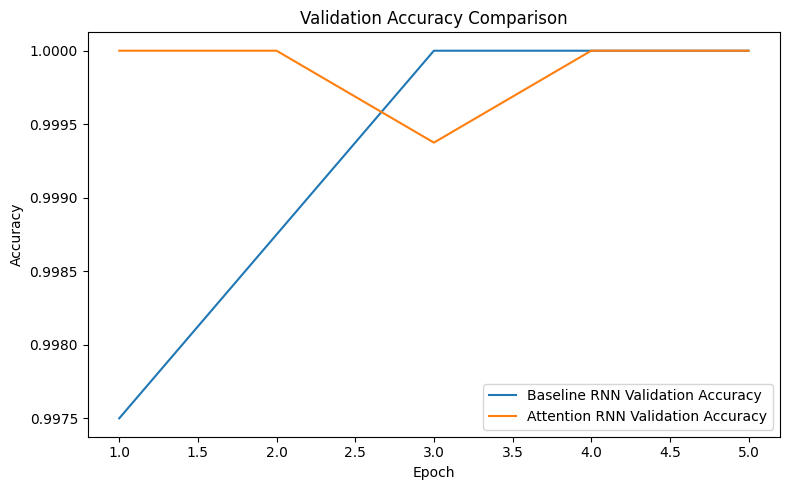

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, baseline_history["val_acc"], label="Baseline RNN Validation Accuracy")
plt.plot(epochs, attention_history["val_acc"], label="Attention RNN Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("validation_accuracy_comparison.png", dpi=300)
plt.show()

In [18]:
baseline_test_loss, baseline_test_acc = evaluate(
    baseline_model, test_loader, criterion, device
)

attention_test_loss, attention_test_acc = evaluate(
    attention_model, test_loader, criterion, device
)

print("Baseline RNN Test Accuracy:", round(baseline_test_acc, 4))
print("Attention RNN Test Accuracy:", round(attention_test_acc, 4))

Baseline RNN Test Accuracy: 1.0
Attention RNN Test Accuracy: 1.0


In [19]:
def decode_tokens(token_ids, idx_to_word):
    """
    Convert token IDs back into readable words for visualisation.
    """
    words = []
    for idx in token_ids:
        if idx in idx_to_word:
            words.append(idx_to_word[idx])
        else:
            words.append(UNK_TOKEN)
    return words

def show_attention_for_example(model, text, vocab, idx_to_word, max_len=MAX_LEN, top_k=20):
    """
    Display the highest-attention words for a single example review.
    """
    model.eval()

    encoded = encode_text(text, vocab, max_len)
    input_tensor = torch.tensor(encoded, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        logits, attn_weights = model(input_tensor, return_attention=True)
        prediction = torch.sigmoid(logits).item()

    attn_weights = attn_weights.squeeze(0).cpu().numpy()
    words = decode_tokens(encoded, idx_to_word)

    # Remove padding tokens for cleaner display
    filtered = [(word, weight) for word, weight in zip(words, attn_weights) if word != PAD_TOKEN]

    # Show top-k attended words
    top_words = sorted(filtered, key=lambda x: x[1], reverse=True)[:top_k]

    print("Predicted probability of positive sentiment:", round(prediction, 4))
    print("\nTop attended words:")
    for word, weight in top_words:
        print(f"{word:15s} {weight:.4f}")

    return filtered

In [20]:
sample_text = test_texts[0]
sample_attention = show_attention_for_example(
    attention_model, sample_text, vocab, idx_to_word
)

Predicted probability of positive sentiment: 0.0001

Top attended words:
i               0.0119
i               0.0115
i               0.0110
and             0.0103
and             0.0102
and             0.0101
and             0.0101
and             0.0101
and             0.0098
and             0.0097
with            0.0088
with            0.0087
they            0.0083
they            0.0082
is              0.0078
is              0.0077
is              0.0076
up              0.0076
you             0.0074
while           0.0071


In [22]:
# Define common stopwords that are not useful for interpretation
stopwords = {
    "i","and","the","a","an","is","it","they","you","we","he","she",
    "with","to","of","in","on","for","this","that","was","were","are",
    "be","as","at","by","but","or","if","from","up","while"
}

# Filter the attention pairs before plotting
filtered_attention = {}

for word, weight in sample_attention:
    if word not in stopwords:
        filtered_attention[word] = max(filtered_attention.get(word, 0), weight)

filtered_attention = list(filtered_attention.items())



In [23]:
def plot_attention_in_sequence(model, text, vocab, idx_to_word, max_len=MAX_LEN, max_words=30):
    model.eval()
    encoded = encode_text(text, vocab, max_len)
    input_tensor = torch.tensor(encoded, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        logits, attn_weights = model(input_tensor, return_attention=True)

    weights = attn_weights.squeeze(0).cpu().numpy()
    words = [idx_to_word.get(i, UNK_TOKEN) for i in encoded]

    filtered_pairs = [(w, a) for w, a in zip(words, weights) if w != PAD_TOKEN]
    filtered_pairs = filtered_pairs[:max_words]

    plot_words = [w for w, _ in filtered_pairs]
    plot_weights = [a for _, a in filtered_pairs]

    plt.figure(figsize=(12, 4))
    plt.bar(range(len(plot_words)), plot_weights)
    plt.xticks(range(len(plot_words)), plot_words, rotation=45, ha="right")
    plt.xlabel("Token position")
    plt.ylabel("Attention weight")
    plt.title("Attention weights across review tokens")
    plt.tight_layout()
    plt.show()

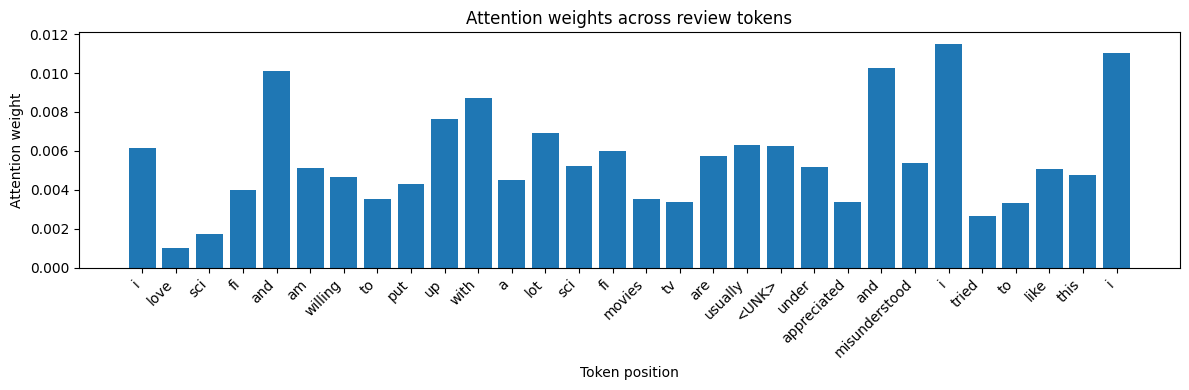

In [27]:
plot_attention_in_sequence(
    attention_model,
    sample_text,
    vocab,
    idx_to_word
)